In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [2]:
import preprocess
from clean import DataCleaner

In [3]:
df = pd.read_csv('data/movies.csv')

In [4]:
cleaner = DataCleaner(df)
df = cleaner.clean()

In [5]:
df.info()

<class 'pandas.DataFrame'>
Index: 9746 entries, 0 to 10177
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   names       9746 non-null   str    
 1   date_x      9746 non-null   str    
 2   score       9746 non-null   float64
 3   genre       9746 non-null   str    
 4   overview    9746 non-null   str    
 5   crew        9712 non-null   str    
 6   orig_title  9746 non-null   str    
 7   status      9746 non-null   str    
 8   orig_lang   9746 non-null   str    
 9   budget_x    9746 non-null   float64
 10  revenue     9746 non-null   float64
 11  country     9746 non-null   str    
dtypes: float64(3), str(9)
memory usage: 989.8 KB


### Plan
firstly, date -> split into years and months

then, perform eda on these features to confirm selection:
- year, month, genre, orig-lang, budget, revenue, country -> 7 total

additional features to test if the we have enough time:
- crew, overview(tf-idf) -> 2 total

score(rating) is our target value

In [6]:
df.head(3)

,names,date_x,score,genre,overview,crew,orig_title,status,orig_lang,budget_x,revenue,country
0,Creed III,03/02/2023,73.0,"Drama, Action","After dominating the boxing world, Adonis Cree...","Michael B. Jordan, Adonis Creed, Tessa Thompso...",Creed III,Released,English,75000000.0,2.716167e+08,AU
1,Avatar: The Way of Water,12/15/2022,78.0,"Science Fiction, Adventure, Action",Set more than a decade after the events of the...,"Sam Worthington, Jake Sully, Zoe Saldaña, Neyt...",Avatar: The Way of Water,Released,English,460000000.0,2.316795e+09,AU
2,The Super Mario Bros. Movie,04/05/2023,76.0,"Animation, Adventure, Family, Fantasy, Comedy","While working underground to fix a water main,...","Chris Pratt, Mario (voice), Anya Taylor-Joy, P...",The Super Mario Bros. Movie,Released,English,100000000.0,7.244590e+08,AU


### Plans for Models to use

1. Linear Regression
2. Random Forest
3. XgBoost -> Gradient Boosting

In [7]:
df = preprocess.split_date_to_year_and_month(df)
genre_features = preprocess.split_genre(df)

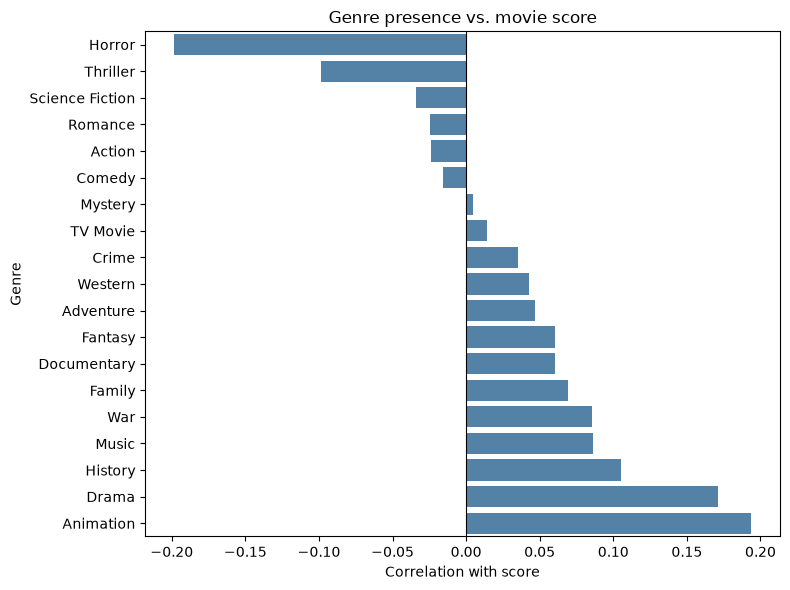

In [8]:
correlations = (
    genre_features.corrwith(df["score"])
    .dropna()
    .sort_values()
)

plt.figure(figsize=(8, 6))
sns.barplot(x=correlations.values, y=correlations.index, color="steelblue")
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Correlation with score")
plt.ylabel("Genre")
plt.title("Genre presence vs. movie score")
plt.tight_layout()
plt.show()

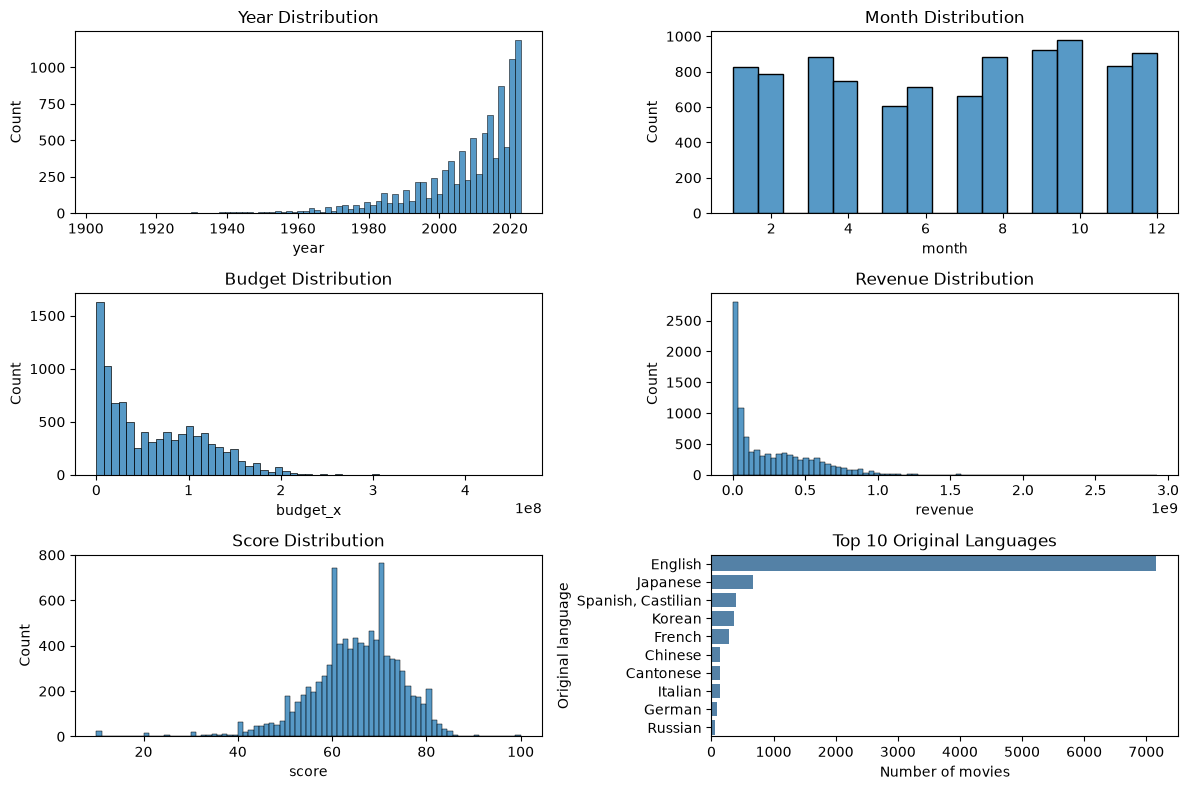

In [9]:
# Create a 1x2 grid (1 row, 2 columns)
fig, axes = plt.subplots(3, 2, figsize=(12, 8))

# First plot on the left axis - Year
sns.histplot(df, x=df['year'], ax=axes[0][0])
axes[0][0].set_title("Year Distribution")

# Second plot on the right axis - Month
sns.histplot(df, x=df['month'], ax=axes[0][1])
axes[0][1].set_title("Month Distribution")

# budget 
sns.histplot(df, x=df['budget_x'], ax=axes[1][0])
axes[1][0].set_title("Budget Distribution")

# revenue
sns.histplot(df, x=df['revenue'], ax=axes[1][1])
axes[1][1].set_title("Revenue Distribution")

# Score
sns.histplot(df, x=df['score'], ax=axes[2][0])
axes[2][0].set_title("Score Distribution")

# original language: top 10 languages
top_languages = df['orig_lang'].str.strip().value_counts().head(10)
sns.barplot(
    x=top_languages.values,
    y=top_languages.index,
    ax=axes[2][1],
    color="steelblue"
)
axes[2][1].set_title("Top 10 Original Languages")
axes[2][1].set_xlabel("Number of movies")
axes[2][1].set_ylabel("Original language")

# Adjust spacing and display
plt.tight_layout()
plt.show()

<Axes: ylabel='country'>

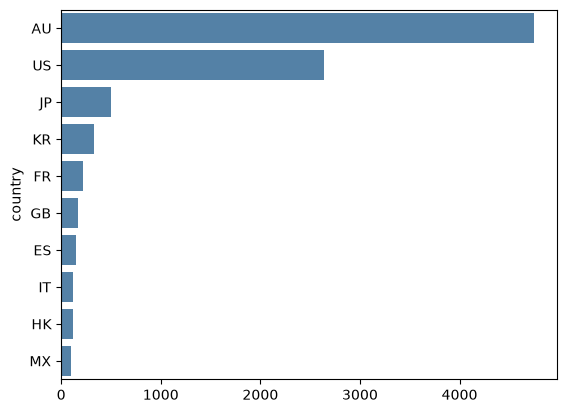

In [10]:
top_countries = df['country'].str.strip().value_counts().head(10)
sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    color="steelblue"
)

<Axes: xlabel='score', ylabel='country'>

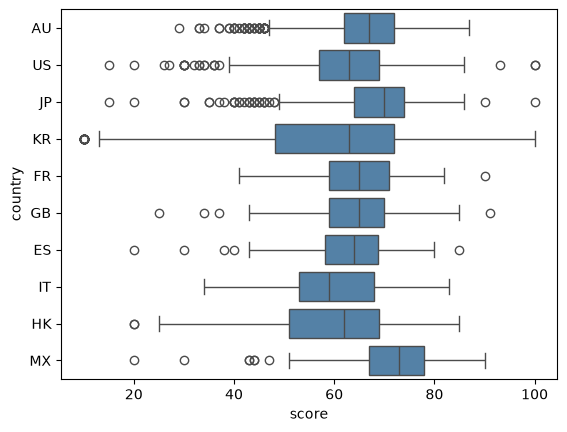

In [11]:
country_order = df["country"].value_counts().head(10).index.tolist()

sns.boxplot(data=df, x="score", y="country",
            order=country_order, color="steelblue")

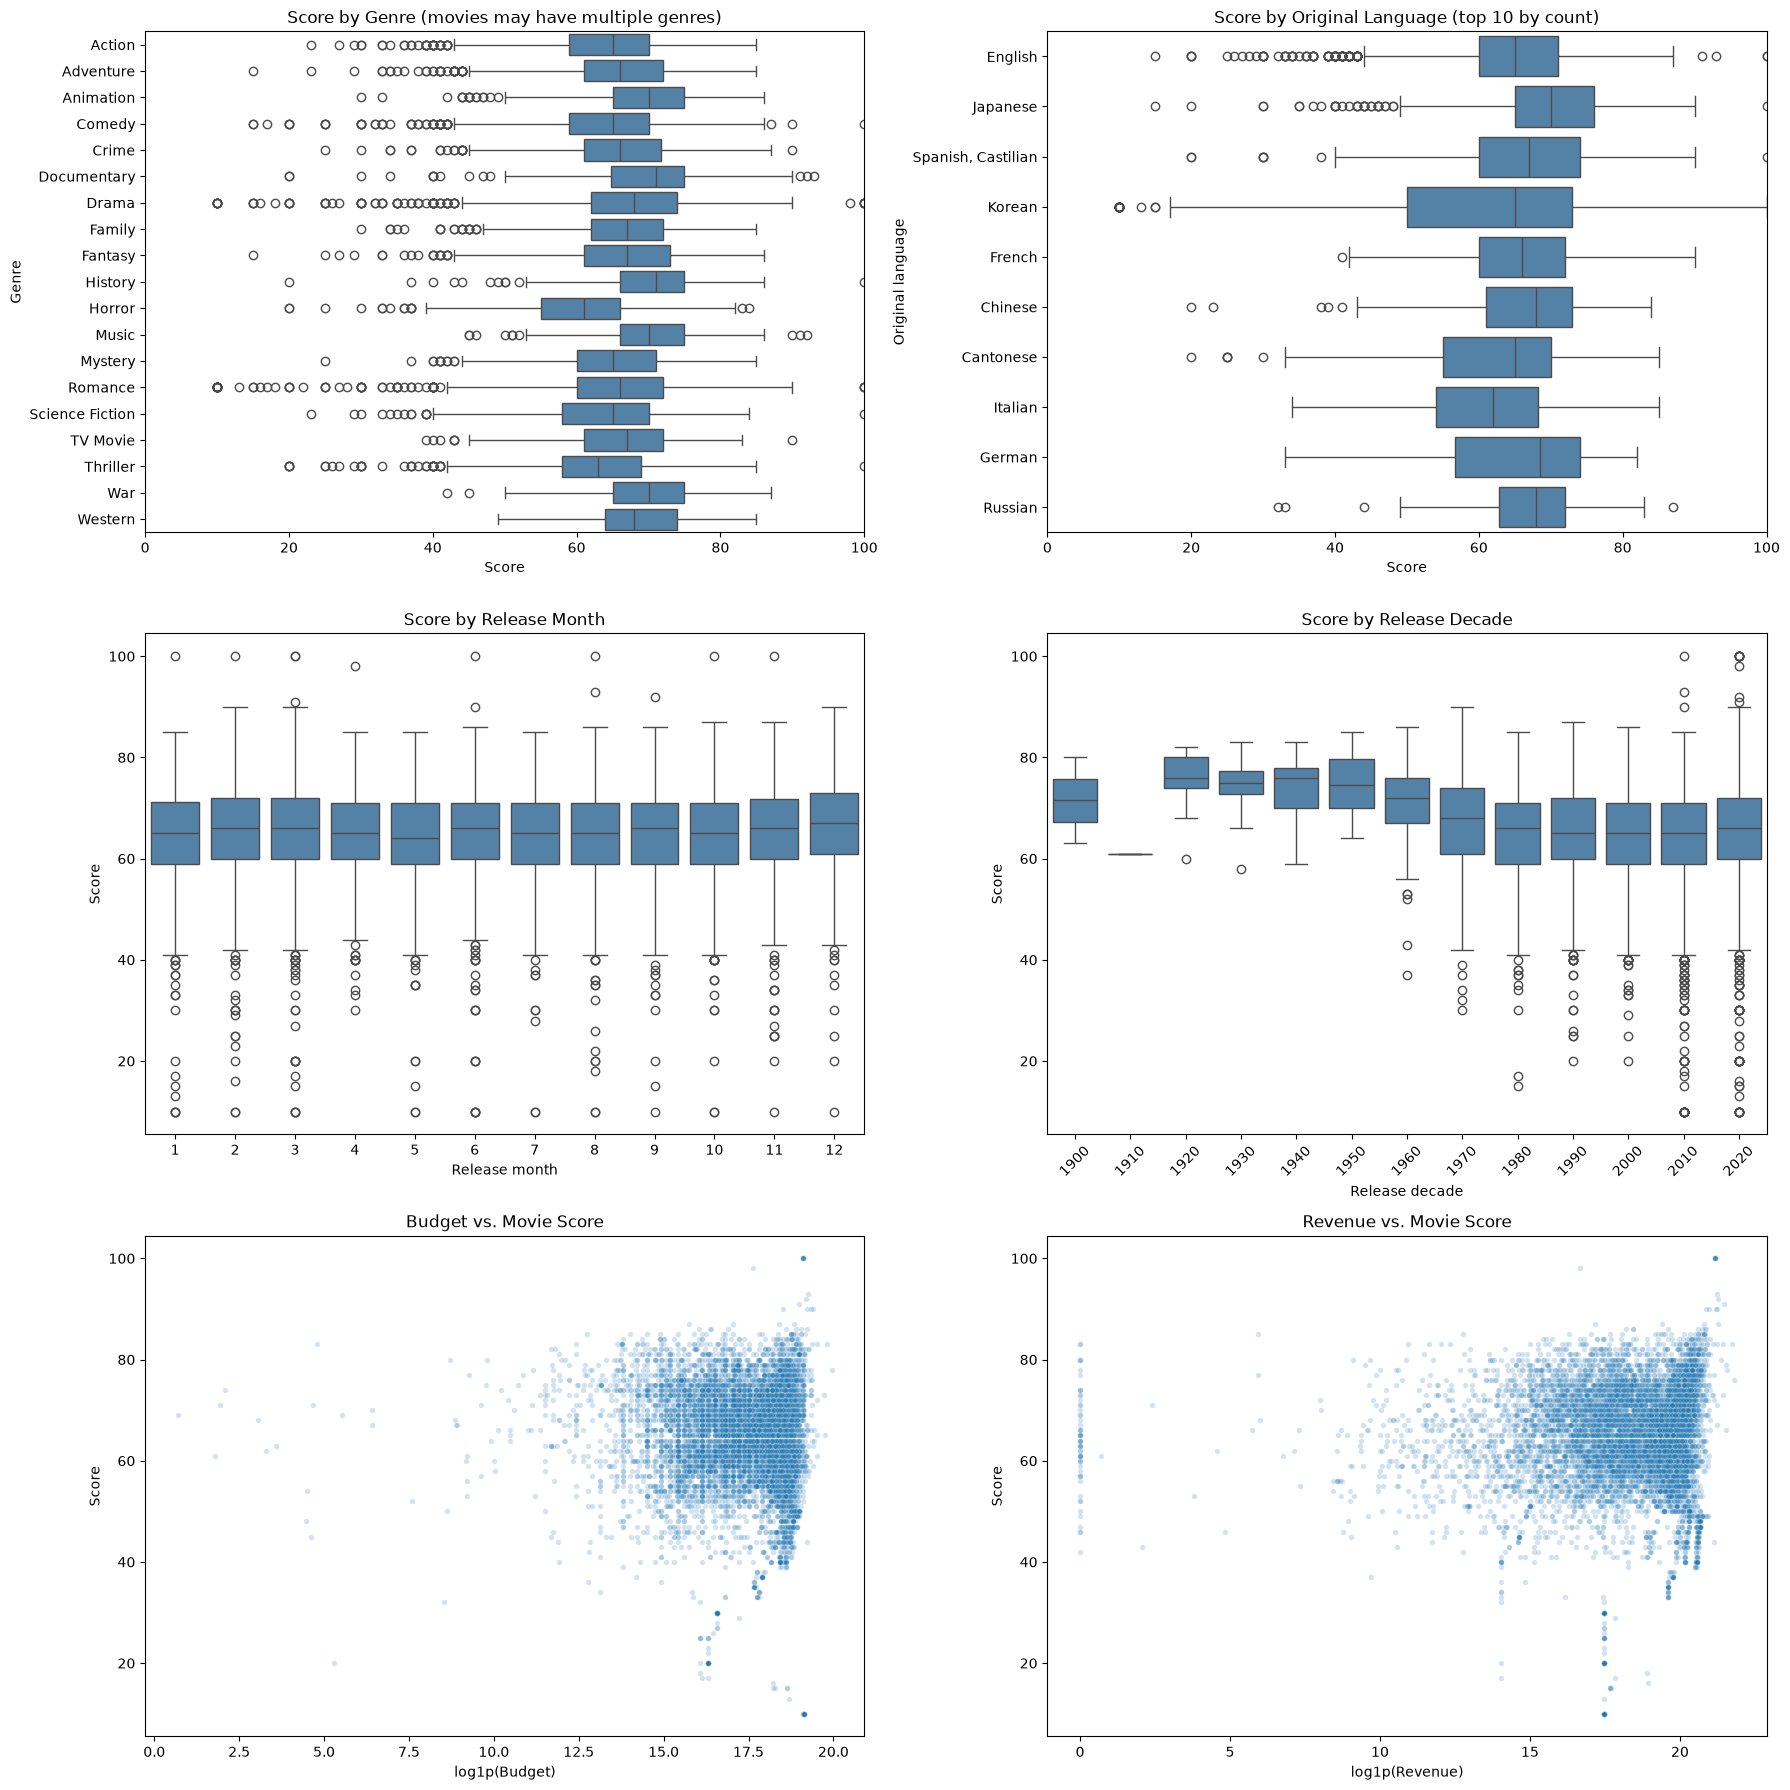

In [12]:
# Compare movie scores with each feature using the current df
plot_df = df.copy()
plot_df["language"] = plot_df["orig_lang"].str.strip()
plot_df["decade"] = (plot_df["year"] // 10) * 10

# A movie appears once per genre it belongs to; skip missing genres
plot_df["genre_list"] = plot_df["genre"].fillna("").apply(
    lambda s: [g.strip() for g in s.split(",") if g.strip()]
)
genre_scores = plot_df[["score", "genre_list"]].explode("genre_list")
genre_scores = genre_scores.dropna(subset=["genre_list"])
genre_order = sorted(genre_scores["genre_list"].unique())
language_order = plot_df["language"].value_counts().head(10).index.tolist()
decade_order = sorted(plot_df["decade"].dropna().unique())

fig, axes = plt.subplots(3, 2, figsize=(18, 18))

sns.boxplot(data=genre_scores, x="score", y="genre_list",
            order=genre_order, ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Score by Genre (movies may have multiple genres)")
axes[0, 0].set_ylabel("Genre")

sns.boxplot(data=plot_df, x="score", y="language",
            order=language_order, ax=axes[0, 1], color="steelblue")
axes[0, 1].set_title("Score by Original Language (top 10 by count)")
axes[0, 1].set_ylabel("Original language")

sns.boxplot(data=plot_df, x="month", y="score",
            order=list(range(1, 13)), ax=axes[1, 0], color="steelblue")
axes[1, 0].set_title("Score by Release Month")
axes[1, 0].set_xlabel("Release month")

sns.boxplot(data=plot_df, x="decade", y="score",
            order=decade_order, ax=axes[1, 1], color="steelblue")
axes[1, 1].set_title("Score by Release Decade")
axes[1, 1].set_xlabel("Release decade")
axes[1, 1].tick_params(axis="x", rotation=45)

for ax, column, label in [
    (axes[2, 0], "budget_x", "Budget"),
    (axes[2, 1], "revenue", "Revenue")
]:
    # log1p retains zero values; negative/missing money is excluded
    valid = plot_df[column].notna() & plot_df[column].ge(0)
    sns.scatterplot(x=np.log1p(plot_df.loc[valid, column]),
                    y=plot_df.loc[valid, "score"],
                    alpha=0.2, s=15, ax=ax)
    ax.set_xlabel(f"log1p({label})")
    ax.set_title(f"{label} vs. Movie Score")

for ax in axes.flat:
    ax.set_xlim(0, 100) if ax in (axes[0, 0], axes[0, 1]) else None
    ax.set_xlabel("Score") if ax in (axes[0, 0], axes[0, 1]) else None
    ax.set_ylabel("Score") if ax not in (axes[0, 0], axes[0, 1]) else None

plt.tight_layout()
plt.show()


In [13]:
# Counts help distinguish well-supported patterns from small groups
print("Genre summaries (a movie can contribute to several genres)")
display(genre_scores.groupby("genre_list")["score"]
        .agg(["count", "mean", "median", "std"]).round(2))

print("Original language summaries (top 10 by count)")
display(plot_df.groupby("language")["score"]
        .agg(["count", "mean", "median", "std"])
        .reindex(language_order).round(2))

print("Release month summaries")
display(plot_df.groupby("month")["score"]
        .agg(["count", "mean", "median", "std"])
        .reindex(range(1, 13)).round(2))

print("Release decade summaries")
display(plot_df.groupby("decade")["score"]
        .agg(["count", "mean", "median", "std"]).round(2))


Genre summaries (a movie can contribute to several genres)


,count,mean,median,std
genre_list,,,,
Action,2662,64.49,65.0,8.56
Adventure,1820,65.85,66.0,8.63
Animation,1439,69.49,70.0,7.26
Comedy,2886,64.64,65.0,8.86
Crime,1246,65.79,66.0,8.34
Documentary,204,68.98,71.0,11.19
Drama,3688,67.05,68.0,9.79
Family,1359,66.58,67.0,7.94
Fantasy,1320,66.38,67.0,9.09


Original language summaries (top 10 by count)


,count,mean,median,std
language,,,,
English,7156,64.79,65.0,8.65
Japanese,671,69.20,70.0,9.79
"Spanish, Castilian",387,66.25,67.0,10.92
Korean,361,59.00,65.0,20.05
French,277,65.57,66.0,8.76
Chinese,141,65.92,68.0,10.52
Cantonese,138,61.96,65.0,12.42
Italian,136,61.54,62.0,11.06
German,88,64.88,68.5,12.12


Release month summaries


,count,mean,median,std
month,,,,
1,828,64.45,65.0,10.45
2,789,65.10,66.0,10.48
3,882,64.91,66.0,10.68
4,748,64.97,65.0,8.97
5,606,63.88,64.0,10.17
6,713,64.61,66.0,10.41
7,665,64.57,65.0,9.82
8,881,64.40,65.0,9.90
9,921,64.64,66.0,9.35


Release decade summaries


,count,mean,median,std
decade,,,,
1900,2,71.50,71.5,12.02
1910,1,61.00,61.0,NaN
1920,9,75.00,76.0,7.09
1930,20,74.65,75.0,5.63
1940,33,74.36,76.0,6.26
1950,70,74.66,74.5,5.77
1960,135,71.04,72.0,7.67
1970,267,65.92,68.0,10.73
1980,597,64.55,66.0,9.71


In [14]:
df['budget_x'].corr(df["score"])

np.float64(-0.042239331978058126)

In [15]:
df['revenue'].corr(df['score'])

np.float64(0.08322188527744653)

## Findings

1. Budget & Revenue don't have that much correlation with the rating of a movie -- might be skipable
2. Genre shows the most correlation(both -ve and +ve) for the ones we've seen till now
3. Older movies have higher scores and scores seem to be slightly falling across years -- might be no of movies as well
4. Months seem to have similar distribution of data
5. Highest budget and revenue ranges shows the highest variations